In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


Purpose:

dimensionality reduction

visualization

clustering

nearest neighbor analysis

Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [4]:
EMB_PATH = "data/processed/ssl_embeddings.npy"
LABEL_PATH = "data/processed/ssl_labels.npy"

In [5]:
embeddings = np.load(EMB_PATH)
labels = np.load(LABEL_PATH)

print(embeddings.shape)

(300, 128)


Normalize embeddings

In [6]:
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

PCA

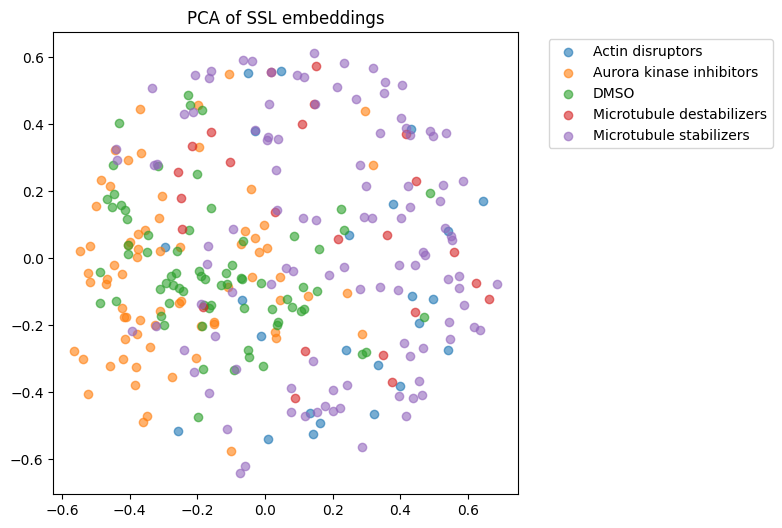

In [7]:
pca = PCA(n_components=2)

pca_emb = pca.fit_transform(embeddings)

plt.figure(figsize=(6,6))

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(pca_emb[idx,0], pca_emb[idx,1], label=label, alpha=0.6)

plt.legend(bbox_to_anchor=(1.05,1))
plt.title("PCA of SSL embeddings")
plt.show()

t-SNE visualization

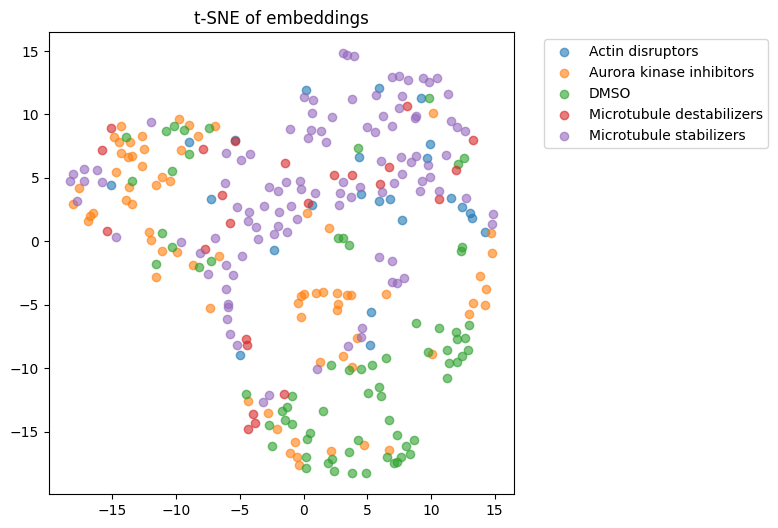

In [8]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

tsne_emb = tsne.fit_transform(embeddings)

plt.figure(figsize=(6,6))

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(tsne_emb[idx,0], tsne_emb[idx,1], label=label, alpha=0.6)

plt.legend(bbox_to_anchor=(1.05,1))
plt.title("t-SNE of embeddings")
plt.show()

KMeans clustering

In [9]:
n_clusters = len(np.unique(labels))

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings)

Cluster purity

In [10]:
from collections import Counter

purity_scores = []

for c in np.unique(clusters):

    cluster_labels = labels[clusters == c]

    most_common = Counter(cluster_labels).most_common(1)[0][1]

    purity = most_common / len(cluster_labels)

    purity_scores.append(purity)

print("Average cluster purity:", np.mean(purity_scores))

Average cluster purity: 0.5143279537866989
